# Mathematical Foundations

Three areas of mathematics carry all the weight in this curriculum:

- **Linear algebra** is what a network *computes* — every layer is a matrix multiply.
- **Calculus** is how it *learns* — backpropagation is the chain rule and nothing else.
- **Probability** is what its outputs *mean*, and where every loss function comes from.

This notebook covers exactly as much of each as the rest of the curriculum needs. It
is the only lesson here that trains no model: everything is verified against a
closed-form answer, against PyTorch, or against a numerical estimate, so you can see
each rule actually hold rather than take it on faith.

Read [Chapter 00 of the book](../book/index.html#ch00) first — this notebook assumes
its explanations and repeats none of them.

**What you will do**

*Part 1 — Linear algebra*
- Dot products as similarity, and matrix multiplication as a grid of dot products
- Shape rules, transposes, and the broadcasting case that silently does the wrong thing

*Part 2 — Calculus*
- Derivatives by finite differences, and gradient checking
- The chain rule, and summing over paths when a variable is used twice
- One gradient-descent step, and what a too-large learning rate does

*Part 3 — Probability and loss*
- Binary cross-entropy from the Bernoulli likelihood
- Softmax, and the max-subtraction trick that stops it overflowing
- Cross-entropy from the categorical likelihood
- The `ŷ - y` gradient, verified three independent ways
- MSE, MAE, and Huber under an outlier
- Entropy, cross-entropy, KL divergence, and perplexity

## Step 1: Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Everything here is small and CPU-bound; no device juggling needed.
torch.manual_seed(0)
np.random.seed(0)

print('torch', torch.__version__)

torch 2.12.0


---
# Part 1 · Linear Algebra

A neural network is a sequence of matrix multiplications with non-linear functions
between them. These operations are not background material — they *are* the forward
pass.

## Step 2: The Dot Product Is a Similarity Score

$$\mathbf{a}\cdot\mathbf{b} = \sum_i a_i b_i = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$$

Large and positive when two vectors point the same way, zero when perpendicular,
negative when opposed. When attention computes $QK^\top$ in lesson 06, every entry
is one of these, asking "how relevant is this position to that one?"

In [2]:
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


pairs = [
    ('same direction', np.array([1.0, 0.0]), np.array([2.0, 0.0])),
    ('45 degrees',     np.array([1.0, 0.0]), np.array([1.0, 1.0])),
    ('perpendicular',  np.array([1.0, 0.0]), np.array([0.0, 1.0])),
    ('opposed',        np.array([1.0, 0.0]), np.array([-1.0, 0.0])),
]

print(f'{"":>16} {"dot":>8} {"cos":>8} {"angle":>8}')
for name, a, b in pairs:
    c = cosine(a, b)
    print(f'{name:>16} {np.dot(a, b):>8.2f} {c:>8.2f} {np.degrees(np.arccos(c)):>7.1f}°')

print()
a = np.array([2.0, 0.0, 1.0])
b = np.array([3.0, 4.0, -2.0])
print(f'a = {a},  b = {b}')
print(f'a · b = (2)(3) + (0)(4) + (1)(-2) = {np.dot(a, b):.0f}')
print()
print('Positive, so the angle is acute: the vectors broadly agree in direction.')

                      dot      cos    angle
  same direction     2.00     1.00     0.0°
      45 degrees     1.00     0.71    45.0°
   perpendicular     0.00     0.00    90.0°
         opposed    -1.00    -1.00   180.0°

a = [2. 0. 1.],  b = [ 3.  4. -2.]
a · b = (2)(3) + (0)(4) + (1)(-2) = 4

Positive, so the angle is acute: the vectors broadly agree in direction.


---
## Step 3: Matrix Multiplication, Shapes, and Broadcasting

`(m, n) @ (n, p) -> (m, p)`. The inner dimensions must match, and they vanish.
Entry `(i, j)` of the result is the dot product of row `i` with column `j`.

In [3]:
A = np.array([[1.0, 2.0, 0.0],
              [0.0, 1.0, 3.0]])          # (2, 3)
B = np.array([[1.0,  0.0],
              [2.0, -1.0],
              [0.0,  1.0]])              # (3, 2)

C = A @ B
print(f'A {A.shape} @ B {B.shape} -> C {C.shape}')
print(C)
print()

# Every entry is one dot product — verify by hand.
for i in range(2):
    for j in range(2):
        terms = ' + '.join(f'({A[i,k]:.0f})({B[k,j]:.0f})' for k in range(3))
        print(f'  C[{i},{j}] = row{i} · col{j} = {terms} = {C[i,j]:.0f}')

print()
print('Order matters — B @ A is a completely different (and here, differently shaped)')
print(f'operation: B {B.shape} @ A {A.shape} -> {(B @ A).shape}')
print()

# The shape errors you will actually hit
print('Illegal shapes raise, and reading the message is a skill:')
try:
    _ = A @ A
except ValueError as e:
    print(f'  A @ A -> {e}')

A (2, 3) @ B (3, 2) -> C (2, 2)
[[ 5. -2.]
 [ 2.  2.]]

  C[0,0] = row0 · col0 = (1)(1) + (2)(2) + (0)(0) = 5
  C[0,1] = row0 · col1 = (1)(0) + (2)(-1) + (0)(1) = -2
  C[1,0] = row1 · col0 = (0)(1) + (1)(2) + (3)(0) = 2
  C[1,1] = row1 · col1 = (0)(0) + (1)(-1) + (3)(1) = 2

Order matters — B @ A is a completely different (and here, differently shaped)
operation: B (3, 2) @ A (2, 3) -> (3, 3)

Illegal shapes raise, and reading the message is a skill:
  A @ A -> matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)


In [4]:
# Broadcasting: align from the right; each dim must match or be 1.
X = np.zeros((4, 3))

cases = [
    ('(4,3) + (3,)',   np.ones(3)),
    ('(4,3) + (4,1)',  np.ones((4, 1))),
    ('(4,3) + (1,3)',  np.ones((1, 3))),
    ('(4,3) + (4,)',   np.ones(4)),
]
for label, v in cases:
    try:
        print(f'  {label:<18} -> {(X + v).shape}')
    except ValueError as e:
        print(f'  {label:<18} -> ERROR ({str(e)[:44]}...)')

print()
print('And the case that is legal, silent, and almost never what you meant:')
col = np.array([[1.0], [2.0], [3.0], [4.0]])   # (4, 1)
row = np.array([[10.0, 20.0, 30.0]])           # (1, 3)
print(f'  (4,1) + (1,3) -> {(col + row).shape}   BOTH dimensions stretched')
print(col + row)
print()
print('A (4,1) where you meant (1,4) produces a grid of nonsense rather than an')
print('error. When something is wrong for no visible reason, print your shapes.')

  (4,3) + (3,)       -> (4, 3)
  (4,3) + (4,1)      -> (4, 3)
  (4,3) + (1,3)      -> (4, 3)
  (4,3) + (4,)       -> ERROR (operands could not be broadcast together wit...)

And the case that is legal, silent, and almost never what you meant:
  (4,1) + (1,3) -> (4, 3)   BOTH dimensions stretched
[[11. 21. 31.]
 [12. 22. 32.]
 [13. 23. 33.]
 [14. 24. 34.]]

A (4,1) where you meant (1,4) produces a grid of nonsense rather than an
error. When something is wrong for no visible reason, print your shapes.


In [5]:
# A linear layer, by hand and by PyTorch — note the transposed storage.
batch, n_in, n_out = 5, 3, 4
X = torch.randn(batch, n_in)
layer = nn.Linear(n_in, n_out)

manual = X @ layer.weight.T + layer.bias      # PyTorch stores W as (out, in)
auto = layer(X)

print(f'X            {tuple(X.shape)}')
print(f'layer.weight {tuple(layer.weight.shape)}   <- (out, in), the transpose of the maths')
print(f'layer.bias   {tuple(layer.bias.shape)}')
print(f'output       {tuple(auto.shape)}')
print()
print('X @ W.T + b matches nn.Linear:', torch.allclose(manual, auto, atol=1e-6))
print()
print(f'parameters: {n_in}*{n_out} + {n_out} = {n_in*n_out + n_out}')
print('The batch dimension passes through untouched — layers transform features,')
print('never the batch.')

X            (5, 3)
layer.weight (4, 3)   <- (out, in), the transpose of the maths
layer.bias   (4,)
output       (5, 4)

X @ W.T + b matches nn.Linear: True

parameters: 3*4 + 4 = 16
The batch dimension passes through untouched — layers transform features,
never the batch.


In [6]:
# Elementwise (Hadamard) vs matrix multiply — completely different operations.
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])

print(f'a ⊙ b (elementwise) = {a * b}      shape {(a*b).shape}')
print(f'a · b (dot)         = {np.dot(a, b):.0f}                  a scalar')
print()
print('An LSTM forget gate does f ⊙ c: each memory slot is scaled by its own gate')
print('value independently. A dot product would collapse the memory into one number.')

a ⊙ b (elementwise) = [ 4. 10. 18.]      shape (3,)
a · b (dot)         = 32                  a scalar

An LSTM forget gate does f ⊙ c: each memory slot is scaled by its own gate
value independently. A dot product would collapse the memory into one number.


---
### Concept Check: Linear Algebra

1. `A` is `(8, 16)` and `B` is `(16, 4)`. What shape is `A @ B`? Is `B @ A` legal?
2. Why does the backward pass through a weight matrix use `W.T`?
3. You meant to add a bias of shape `(1, 64)` but passed one of shape `(64, 1)` to a
   `(32, 64)` activation. What happens?

In [7]:
# 1. (8, 4) — the inner 16s match and vanish. B @ A is (16,4) @ (8,16), and 4 != 8,
#    so it raises. Matrix multiplication does not commute, and often the shapes do
#    not even permit both orders.
#
# 2. Shapes force it. If the forward pass sent information through W from n inputs
#    to m outputs, the backward pass must send gradient the other way, from m back
#    to n. W.T is the operator with the right shape to do that — and it is also
#    exactly what the chain rule produces when you differentiate x @ W.
#
# 3. (32, 64) + (64, 1) fails: aligning from the right, 64 vs 1 broadcasts fine,
#    but 32 vs 64 neither match nor is either 1, so it raises. You are lucky. Had
#    the activation been (64, 64), the (64, 1) would have broadcast silently across
#    columns instead of rows and produced a wrong answer with no error at all.

---
# Part 2 · Calculus

Training means adjusting parameters to reduce a loss, and the derivative is the only
thing that says which way. Everything below is in service of one formula:

$$\frac{\partial \mathcal{L}}{\partial \theta} = \text{(product of derivatives along every path from } \theta \text{ to } \mathcal{L})$$

That is backpropagation.

## Step 4: Derivatives, and Gradient Checking

$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$ for small `h`. This is not just a
definition — it is how you verify a hand-written backward pass, and you will use it
on the softmax gradient later in this notebook.

In [8]:
def numeric_derivative(f, x, h=1e-5):
    """Central difference. More accurate than the forward difference for the same h."""
    return (f(x + h) - f(x - h)) / (2 * h)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


checks = [
    ('x²',       lambda x: x**2,       lambda x: 2*x,                    3.0),
    ('eˣ',       np.exp,               np.exp,                           1.0),
    ('ln x',     np.log,               lambda x: 1/x,                    2.0),
    ('σ(x)',     sigmoid,              lambda x: sigmoid(x)*(1-sigmoid(x)), 0.5),
    ('tanh x',   np.tanh,              lambda x: 1 - np.tanh(x)**2,      0.8),
    ('(3x+1)²',  lambda x: (3*x+1)**2, lambda x: 6*(3*x+1),              2.0),
]

print(f'{"function":>10} {"at x":>6} {"analytic":>12} {"numeric":>12} {"agree":>7}')
for name, f, df, x in checks:
    a, n = df(x), numeric_derivative(f, x)
    print(f'{name:>10} {x:>6.1f} {a:>12.6f} {n:>12.6f} {str(np.isclose(a, n)):>7}')

print()
print('The last row is the chain rule: d/dx (3x+1)² = 2(3x+1) · 3 = 6(3x+1).')
print('Multiply the derivatives of the composed functions.')

  function   at x     analytic      numeric   agree
        x²    3.0     6.000000     6.000000    True
        eˣ    1.0     2.718282     2.718282    True
      ln x    2.0     0.500000     0.500000    True
      σ(x)    0.5     0.235004     0.235004    True
    tanh x    0.8     0.559055     0.559055    True
   (3x+1)²    2.0    42.000000    42.000000    True

The last row is the chain rule: d/dx (3x+1)² = 2(3x+1) · 3 = 6(3x+1).
Multiply the derivatives of the composed functions.


---
## Step 5: The Multivariable Chain Rule — Sum Over Paths

When a variable influences the loss by more than one route, the total derivative is
the **sum over all paths**. This is exactly why PyTorch *accumulates* into `.grad`
rather than overwriting it — and therefore why `zero_grad()` is mandatory.

In [9]:
# u = w², v = u + w, L = 3v.  w reaches L by two paths.
w0 = 2.0

def L_of(w):
    u = w**2
    v = u + w
    return 3*v

# analytic, path by path
dL_dv = 3.0
dv_du, du_dw = 1.0, 2*w0        # path 1: w -> u -> v -> L
dv_dw = 1.0                     # path 2: w -> v -> L

path1 = du_dw * dv_du * dL_dv
path2 = dv_dw * dL_dv
analytic = path1 + path2

print(f'path 1  (w -> u -> v -> L): {du_dw} x {dv_du} x {dL_dv} = {path1}')
print(f'path 2  (w -> v -> L):          {dv_dw} x {dL_dv} = {path2}')
print(f'total   dL/dw = {analytic}')
print()
print(f'numeric check: {numeric_derivative(L_of, w0):.4f}')

# and autograd agrees
wt = torch.tensor(w0, requires_grad=True)
(3 * (wt**2 + wt)).backward()
print(f'autograd     : {wt.grad.item():.4f}')
print()

# Now the bug this behaviour causes.
wt2 = torch.tensor(w0, requires_grad=True)
(3 * (wt2**2 + wt2)).backward()
print(f'after one backward()  : w.grad = {wt2.grad.item():.1f}')
(3 * (wt2**2 + wt2)).backward()
print(f'after two backwards   : w.grad = {wt2.grad.item():.1f}   <- the missing zero_grad() bug')
print()
print('Nothing crashes. 30 is the derivative of nothing in particular, and a model')
print('trained this way descends steadily towards the wrong thing.')

path 1  (w -> u -> v -> L): 4.0 x 1.0 x 3.0 = 12.0
path 2  (w -> v -> L):          1.0 x 3.0 = 3.0
total   dL/dw = 15.0

numeric check: 15.0000
autograd     : 15.0000

after one backward()  : w.grad = 15.0
after two backwards   : w.grad = 30.0   <- the missing zero_grad() bug

Nothing crashes. 30 is the derivative of nothing in particular, and a model
trained this way descends steadily towards the wrong thing.


---
## Step 6: Gradient Descent, and What the Learning Rate Does

$$\\theta \\leftarrow \\theta - \\eta \\frac{\\partial \\mathcal{L}}{\\partial \\theta}$$

lr=0.1   final w =       3.7938   loss =       0.042501
lr=0.5   final w =       4.0000   loss =       0.000000
lr=0.9   final w =       3.7938   loss =       0.042501
lr=1.05  final w =      -5.4153   loss =      88.647594


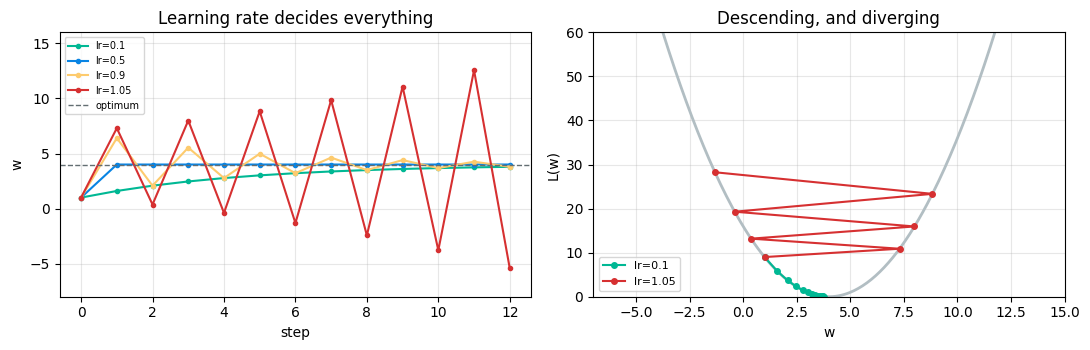


At lr=1.05 each step overshoots by more than it corrects, so the loss grows
without bound. That is what a nan loss five steps into training usually means,
and lowering the learning rate is usually the whole fix.


In [10]:
def descend(lr, steps=12, w=1.0):
    """Minimise L(w) = (w - 4)², whose minimum is obviously at w = 4."""
    path = [w]
    for _ in range(steps):
        grad = 2 * (w - 4)
        w = w - lr * grad
        path.append(w)
    return path


fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ws = np.linspace(-6, 14, 300)
for lr, color in [(0.1, '#00b894'), (0.5, '#0984e3'), (0.9, '#fdcb6e'), (1.05, '#d63031')]:
    path = descend(lr)
    ax[0].plot(path, marker='o', ms=3, color=color, label=f'lr={lr}')
    print(f'lr={lr:<5} final w = {path[-1]:>12.4f}   loss = {(path[-1]-4)**2:>14.6f}')

ax[0].axhline(4, color='#636e72', ls='--', lw=1, label='optimum')
ax[0].set_ylim(-8, 16)
ax[0].set_xlabel('step'); ax[0].set_ylabel('w')
ax[0].set_title('Learning rate decides everything')
ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3)

ax[1].plot(ws, (ws - 4)**2, color='#b2bec3', lw=2)
p = descend(0.1)
ax[1].plot(p, [(x-4)**2 for x in p], 'o-', color='#00b894', ms=4, label='lr=0.1')
p = descend(1.05, steps=6)
ax[1].plot(p, [(x-4)**2 for x in p], 'o-', color='#d63031', ms=4, label='lr=1.05')
ax[1].set_ylim(0, 60); ax[1].set_xlabel('w'); ax[1].set_ylabel('L(w)')
ax[1].set_title('Descending, and diverging')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print()
print('At lr=1.05 each step overshoots by more than it corrects, so the loss grows')
print('without bound. That is what a nan loss five steps into training usually means,')
print('and lowering the learning rate is usually the whole fix.')

---
### Concept Check: Calculus

1. Your analytic gradient and a finite-difference estimate disagree by 30%. Which do
   you trust, and what do you do?
2. Why must `zero_grad()` be called every iteration, given that summing over paths is
   the mathematically correct behaviour?
3. A network has 10 sigmoid layers. The derivative of sigmoid peaks at 0.25. What is
   the best possible gradient magnitude reaching layer 1, relative to the loss?

In [11]:
# 1. Trust the numerical estimate and fix the analytic one. Finite differences make
#    no assumptions and can only be wrong through floating-point error, which is
#    small for h around 1e-5 with a central difference. A 30% disagreement is far
#    too large for round-off — it is a missing term or a wrong factor in your
#    derivation. (Check one parameter at a time; the first mismatch localises it.)
#
# 2. Summing over paths is correct WITHIN one backward pass — a parameter used at
#    several points must collect a contribution from each. Autograd has no way to
#    know where one backward pass ends and the next begins, so it keeps summing
#    across iterations too, which is not what you want. zero_grad() supplies that
#    boundary. The same default is what makes gradient accumulation and weight
#    sharing work, so it is a feature with a sharp edge, not a design mistake.
#
# 3. 0.25^10 = 9.5e-7, and that is the BEST case, requiring every unit in every
#    layer to sit exactly at its most responsive point. In practice units saturate
#    and the real factor is far smaller. This is the vanishing gradient problem in
#    one line, and it is why ReLU and GELU replaced sigmoid in hidden layers, and
#    why residual connections exist.

---
# Part 3 · Probability and Loss

---
## Key Concept: From Likelihood to Loss

For a dataset of `N` independent examples, the likelihood of the parameters is the
**product** of the per-example probabilities:

$$\mathcal{l}(\theta) = \prod_{i=1}^{N} P(y_i \mid x_i, \theta)$$

We do not use that product directly, for two reasons:

1. **It underflows.** 64 examples at probability 0.1 each gives `1e-64`; float32
   bottoms out around `1e-38`. The likelihood becomes exactly zero, and so does its
   gradient.
2. **Derivatives of products are miserable.** The product rule compounds across all
   `N` terms.

Taking a logarithm fixes both. It is monotonic, so the maximiser is unchanged, and
it turns the product into a sum. Flip the sign to make it a minimisation and divide
by `N` to make it comparable across batch sizes:

$$\mathcal{L}(\theta) = -\frac{1}{N}\sum_{i=1}^{N}\log P(y_i \mid x_i, \theta)$$

**Every loss below is that formula with a different distribution substituted in.**

## Step 7: The Underflow That Motivates the Log

In [12]:
# 64 examples, each assigned probability 0.1 by the model.
probs = np.full(64, 0.1, dtype=np.float32)

product = np.prod(probs)                 # the raw likelihood
log_sum = np.sum(np.log(probs))          # the log-likelihood

print(f'raw product        : {product}')          # underflows to 0.0
print(f'sum of logs        : {log_sum:.4f}')      # perfectly well behaved
print(f'exp(sum of logs)   : {np.exp(log_sum)}')  # 0.0 again — the value is genuinely tiny
print()
print(f'product == 0.0 ?   : {product == 0.0}')
print('A zero likelihood has zero gradient. Training would stop before it started.')

raw product        : 0.0
sum of logs        : -147.3655
exp(sum of logs)   : 0.0

product == 0.0 ?   : True
A zero likelihood has zero gradient. Training would stop before it started.


---
## Step 8: Bernoulli → Binary Cross-Entropy

A single yes/no outcome with probability `p` of being 1:

$$P(y \mid p) = p^{y}(1-p)^{1-y}$$

The exponents act as an `if` statement written as an expression — when `y=1` it
reads `p`, when `y=0` it reads `1-p`. Substituting into the negative
log-likelihood gives

$$\mathcal{L} = -\frac{1}{N}\sum_i\Big[y_i\log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\Big]$$

**TODO:** implement it, then check against `nn.BCELoss`.

In [13]:
def bce(y_true, y_pred, eps=1e-7):
    """Binary cross-entropy, averaged over the batch.

    y_true : (N,) array of 0/1 labels
    y_pred : (N,) array of predicted probabilities in (0, 1)
    """
    # log(0) is -inf and would poison every downstream gradient with nan.
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


y_true = np.array([1.0, 0.0, 1.0, 0.0, 1.0])
y_pred = np.array([0.9, 0.2, 0.4, 0.1, 0.95])

ours = bce(y_true, y_pred)
theirs = nn.BCELoss()(torch.tensor(y_pred), torch.tensor(y_true)).item()

print(f'our bce      : {ours:.6f}')
print(f'nn.BCELoss   : {theirs:.6f}')
print(f'agree        : {np.isclose(ours, theirs)}')
print()

# Per-example contributions: which one dominates the batch?
per = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
for t, p, l in zip(y_true, y_pred, per):
    print(f'  y={t:.0f}  ŷ={p:.2f}   loss={l:.4f}   ({100*l/per.sum():.0f}% of the total)')

our bce      : 0.280290
nn.BCELoss   : 0.280290
agree        : True

  y=1  ŷ=0.90   loss=0.1054   (8% of the total)
  y=0  ŷ=0.20   loss=0.2231   (16% of the total)
  y=1  ŷ=0.40   loss=0.9163   (65% of the total)
  y=0  ŷ=0.10   loss=0.1054   (8% of the total)
  y=1  ŷ=0.95   loss=0.0513   (4% of the total)


Notice how unevenly the batch loss is distributed. The one example on the wrong side
of 0.5 contributes far more than the four confident-and-correct ones combined. That
asymmetry is the log at work, and it is why a handful of hard examples can dominate
a gradient step.

---
## Step 9: Softmax, and Why It Overflows

$$\hat{y}_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

Exponentiating forces positivity; dividing by the sum forces normalisation. Written
naively it also overflows: `exp(800)` is `inf` in float64, and `inf/inf` is `nan`.

Softmax is invariant to adding a constant to every logit, because $e^c$ factors out
of the numerator and denominator alike. So subtract the maximum first — the largest
exponent becomes $e^0 = 1$, and overflow is impossible.

**TODO:** write both versions and compare.

In [14]:
def softmax_naive(z):
    """Straight from the formula. Overflows for large logits."""
    e = np.exp(z)
    return e / e.sum()


def softmax_stable(z):
    """Subtract the max first. Mathematically identical, numerically safe."""
    e = np.exp(z - z.max())
    return e / e.sum()


small = np.array([2.0, 1.0, 0.0])
large = np.array([800.0, 799.0, 798.0])   # same differences, huge magnitude

print('small logits')
print(f'  naive  : {softmax_naive(small)}')
print(f'  stable : {softmax_stable(small)}')
print()
print('large logits (identical differences, so the answer should be identical)')
with np.errstate(over='ignore', invalid='ignore'):
    print(f'  naive  : {softmax_naive(large)}')
print(f'  stable : {softmax_stable(large)}')
print()
print(f'torch    : {F.softmax(torch.tensor(large), dim=0).numpy()}')
print()
print('Only the differences between logits carry meaning — which is exactly why')
print('the max-subtraction is free, and why every real implementation does it.')

small logits
  naive  : [0.66524096 0.24472847 0.09003057]
  stable : [0.66524096 0.24472847 0.09003057]

large logits (identical differences, so the answer should be identical)
  naive  : [nan nan nan]
  stable : [0.66524096 0.24472847 0.09003057]

torch    : [0.66524096 0.24472847 0.09003057]

Only the differences between logits carry meaning — which is exactly why
the max-subtraction is free, and why every real implementation does it.


---
## Step 10: Categorical → Cross-Entropy

$$P(y \mid p) = \prod_k p_k^{y_k} \qquad\Longrightarrow\qquad
\mathcal{L} = -\frac{1}{N}\sum_i \log \hat{y}_{i, c_i}$$

Because `y` is one-hot, the sum over classes collapses to a single term: the log of
the probability assigned to the correct class. This is why
`nn.CrossEntropyLoss` takes **integer class indices** rather than one-hot vectors —
the one-hot was only ever a device for selecting one term.

Note also that `nn.CrossEntropyLoss` expects **raw logits**, not probabilities. It
applies the log-softmax internally, in a fused and numerically stable form.

In [15]:
def cross_entropy(logits, targets):
    """Cross-entropy from logits.

    logits  : (N, K) raw scores
    targets : (N,)   integer class indices
    """
    # log-sum-exp, computed stably: log(sum(exp(z))) = m + log(sum(exp(z - m)))
    m = logits.max(axis=1, keepdims=True)
    log_probs = logits - m - np.log(np.exp(logits - m).sum(axis=1, keepdims=True))
    # pick out the log-probability of the correct class for each row
    return -np.mean(log_probs[np.arange(len(targets)), targets])


logits = np.array([[2.0, 1.0, 0.0],
                   [0.5, 2.5, 0.1],
                   [1.0, 1.0, 3.0]])
targets = np.array([1, 1, 0])     # note: rows 1 and 3 are wrong, row 2 is right

ours = cross_entropy(logits, targets)
theirs = nn.CrossEntropyLoss()(torch.tensor(logits), torch.tensor(targets)).item()

print(f'our cross_entropy   : {ours:.6f}')
print(f'nn.CrossEntropyLoss : {theirs:.6f}')
print(f'agree               : {np.isclose(ours, theirs)}')
print()
print(f'uniform-guess loss for 3 classes = -ln(1/3) = {-np.log(1/3):.4f}')
print('A loss above that means the model is doing worse than guessing.')

our cross_entropy   : 1.283650
nn.CrossEntropyLoss : 1.283650
agree               : True

uniform-guess loss for 3 classes = -ln(1/3) = 1.0986
A loss above that means the model is doing worse than guessing.


---
## Key Concept: The Gradient That Makes Classification Work

Differentiate softmax-then-cross-entropy with respect to the **logits** and almost
everything cancels:

$$\frac{\partial \mathcal{L}}{\partial z_k} = \hat{y}_k - y_k$$

Predicted probability minus true probability. No saturation factor, no attenuation.
Confidently wrong gives a large gradient; nearly right gives a small one.

This cancellation is the reason you should pass **logits** to
`nn.CrossEntropyLoss` and `nn.BCEWithLogitsLoss` rather than applying softmax or
sigmoid yourself. Doing it yourself still runs, still trains, and is measurably worse.

Below we verify the formula three independent ways: analytically, by finite
differences, and with autograd.

In [16]:
z = np.array([2.0, 1.0, 0.0])
c = 1                                  # true class
y_onehot = np.zeros(3); y_onehot[c] = 1

# --- 1. analytic: ŷ - y ---------------------------------------------------------
p = softmax_stable(z)
analytic = p - y_onehot

# --- 2. finite differences: (L(z+h) - L(z-h)) / 2h -------------------------------
def loss_at(zv):
    return -np.log(softmax_stable(zv)[c])

h = 1e-6
numeric = np.zeros(3)
for k in range(3):
    zp, zm = z.copy(), z.copy()
    zp[k] += h; zm[k] -= h
    numeric[k] = (loss_at(zp) - loss_at(zm)) / (2 * h)

# --- 3. autograd ----------------------------------------------------------------
zt = torch.tensor(z, requires_grad=True)
nn.CrossEntropyLoss()(zt.unsqueeze(0), torch.tensor([c])).backward()
autograd = zt.grad.numpy()

print(f'softmax(z)          : {np.round(p, 4)}')
print(f'analytic  (ŷ - y)   : {np.round(analytic, 6)}')
print(f'finite differences  : {np.round(numeric, 6)}')
print(f'autograd            : {np.round(autograd, 6)}')
print()
print(f'all three agree     : {np.allclose(analytic, numeric, atol=1e-5) and np.allclose(analytic, autograd)}')
print(f'gradients sum to    : {analytic.sum():.2e}')
print()
print('They sum to zero because softmax outputs are constrained to sum to 1:')
print('adding a constant to every logit changes nothing, so the gradient can have')
print('no component in that direction. Only relative logits are learnable.')

softmax(z)          : [0.6652 0.2447 0.09  ]
analytic  (ŷ - y)   : [ 0.665241 -0.755272  0.090031]
finite differences  : [ 0.665241 -0.755272  0.090031]
autograd            : [ 0.665241 -0.755272  0.090031]

all three agree     : True
gradients sum to    : -8.33e-17

They sum to zero because softmax outputs are constrained to sum to 1:
adding a constant to every logit changes nothing, so the gradient can have
no component in that direction. Only relative logits are learnable.


---
### Concept Check: Likelihood and Cross-Entropy

1. Why do we take the logarithm of the likelihood? Give both reasons.
2. `nn.CrossEntropyLoss` takes integer targets rather than one-hot vectors. What in
   the derivation makes that possible?
3. The three gradients above sum to zero. What does that tell you about what a
   classifier can and cannot learn?

In [17]:
# 1. Numerical: the product of many probabilities underflows float32 to exactly
#    zero (see Step 2), and a zero likelihood has a zero gradient. Structural:
#    log turns the product into a sum, and sums differentiate term by term while
#    products require the product rule compounding across all N factors.
#
# 2. The one-hot vector multiplies every class term by 0 except the true one, so
#    the sum over classes collapses to a single term: -log(ŷ_c). The one-hot was
#    only ever selecting an index, so passing the index directly is equivalent
#    and avoids materialising an N×K tensor of mostly zeros.
#
# 3. Only *differences* between logits are learnable. Adding the same constant to
#    every logit leaves the distribution — and therefore the loss — unchanged, so
#    the gradient has no component along that direction. A model cannot learn to
#    make all its logits bigger, only to spread them apart.

---
## Step 11: Gaussian → MSE, and Why It Fails on Classification

Substituting the Gaussian density into the negative log-likelihood gives

$$-\log P(y \mid \mu, \sigma^2) = \frac{(y-\mu)^2}{2\sigma^2} + \tfrac{1}{2}\log(2\pi\sigma^2)$$

The second term does not involve $\mu$, so it has zero gradient and can be dropped;
a fixed $\sigma$ is a constant scale absorbed into the learning rate. What is left
is MSE. **So MSE is not assumption-free** — it encodes a belief that your targets
are the truth plus symmetric, constant-width Gaussian noise.

Used for classification behind a sigmoid, it has a specific and damaging failure:

$$\frac{\partial}{\partial z}(\hat{y}-y)^2 = 2(\hat{y}-y)\,\sigma'(z)$$

and $\sigma'(z) \to 0$ exactly when the model is most confidently wrong.

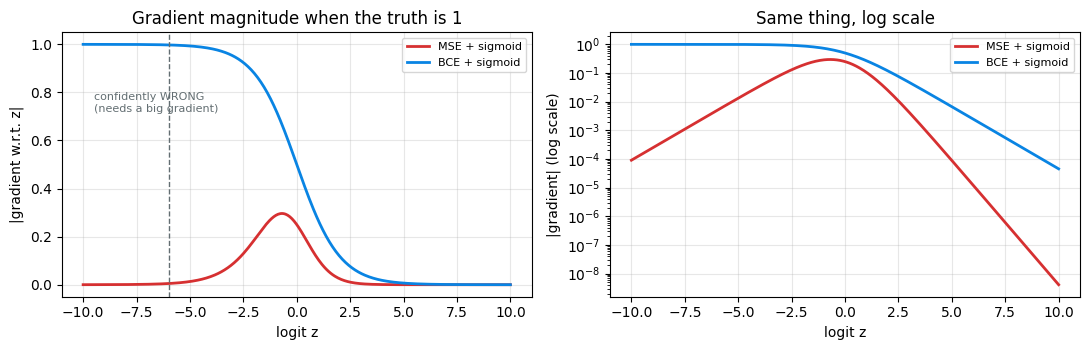

z= -8.0  ŷ=0.000335   MSE grad=6.703e-04   BCE grad=9.997e-01
z= -4.0  ŷ=0.017986   MSE grad=3.469e-02   BCE grad=9.820e-01
z=  0.0  ŷ=0.500000   MSE grad=2.500e-01   BCE grad=5.000e-01

At z=-8 the model is as wrong as it can be, and MSE gives it a gradient of
~7e-4 while BCE gives ~1.0 — a factor of 1400. MSE stalls precisely where
learning matters most.


In [18]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z = np.linspace(-10, 10, 400)
y_true = 1.0                       # the truth is 1 throughout
p = sigmoid(z)

grad_mse = 2 * (p - y_true) * p * (1 - p)   # chain rule through the sigmoid
grad_bce = p - y_true                       # the cancellation

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(z, np.abs(grad_mse), color='#d63031', lw=2, label='MSE + sigmoid')
ax[0].plot(z, np.abs(grad_bce), color='#0984e3', lw=2, label='BCE + sigmoid')
ax[0].axvline(-6, color='#636e72', ls='--', lw=1)
ax[0].annotate('confidently WRONG\n(needs a big gradient)', xy=(-6, 0.5),
               xytext=(-9.5, 0.72), fontsize=8, color='#636e72')
ax[0].set_xlabel('logit z'); ax[0].set_ylabel('|gradient w.r.t. z|')
ax[0].set_title('Gradient magnitude when the truth is 1')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].semilogy(z, np.abs(grad_mse) + 1e-12, color='#d63031', lw=2, label='MSE + sigmoid')
ax[1].semilogy(z, np.abs(grad_bce) + 1e-12, color='#0984e3', lw=2, label='BCE + sigmoid')
ax[1].set_xlabel('logit z'); ax[1].set_ylabel('|gradient| (log scale)')
ax[1].set_title('Same thing, log scale')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

for zz in (-8.0, -4.0, 0.0):
    pp = sigmoid(zz)
    print(f'z={zz:5.1f}  ŷ={pp:.6f}   MSE grad={abs(2*(pp-1)*pp*(1-pp)):.3e}   '
          f'BCE grad={abs(pp-1):.3e}')
print()
print('At z=-8 the model is as wrong as it can be, and MSE gives it a gradient of')
print('~7e-4 while BCE gives ~1.0 — a factor of 1400. MSE stalls precisely where')
print('learning matters most.')

---
## Step 12: MSE vs MAE vs Huber Under an Outlier

Different distributions give different regression losses:

| Loss | Distribution | Gradient w.r.t. error `e` |
|------|--------------|---------------------------|
| MSE  | Gaussian     | `2e` — grows without bound |
| MAE  | Laplace      | `sign(e)` — constant magnitude |
| Huber| hybrid       | `e` near 0, clipped to `±δ` in the tails |

The consequence is entirely practical: one mislabelled point can dominate an MSE
batch and barely register under MAE.

In [19]:
# Nine clean points near 0 and one badly mislabelled point at 10.
errors = np.array([0.1, -0.2, 0.05, 0.3, -0.1, 0.2, -0.05, 0.15, -0.25, 10.0])
delta = 1.0

mse_grads = 2 * errors
mae_grads = np.sign(errors)
hub_grads = np.where(np.abs(errors) <= delta, errors, delta * np.sign(errors))

print(f'{"error":>8} {"MSE grad":>10} {"MAE grad":>10} {"Huber grad":>11}')
for e, m, a, h in zip(errors, mse_grads, mae_grads, hub_grads):
    tag = '  <-- outlier' if abs(e) > 5 else ''
    print(f'{e:8.2f} {m:10.2f} {a:10.2f} {h:11.2f}{tag}')

print()
for name, g in (('MSE', mse_grads), ('MAE', mae_grads), ('Huber', hub_grads)):
    share = abs(g[-1]) / np.abs(g).sum()
    print(f'{name:>5}: the single outlier supplies {100*share:5.1f}% of the total gradient')

print()
print('Under MSE one bad label out of ten steers the batch. Under MAE it gets one')
print('vote like everything else. Huber gives you MSE smoothness near zero and MAE')
print('robustness in the tail.')

   error   MSE grad   MAE grad  Huber grad
    0.10       0.20       1.00        0.10
   -0.20      -0.40      -1.00       -0.20
    0.05       0.10       1.00        0.05
    0.30       0.60       1.00        0.30
   -0.10      -0.20      -1.00       -0.10
    0.20       0.40       1.00        0.20
   -0.05      -0.10      -1.00       -0.05
    0.15       0.30       1.00        0.15
   -0.25      -0.50      -1.00       -0.25
   10.00      20.00       1.00        1.00  <-- outlier

  MSE: the single outlier supplies  87.7% of the total gradient
  MAE: the single outlier supplies  10.0% of the total gradient
Huber: the single outlier supplies  41.7% of the total gradient

Under MSE one bad label out of ten steers the batch. Under MAE it gets one
vote like everything else. Huber gives you MSE smoothness near zero and MAE
robustness in the tail.


---
## Step 13: Entropy, Cross-Entropy, and KL Divergence

A second derivation of the same loss, from information theory.

- **Surprisal** of an event of probability `p` is `-log p` — how many bits an
  optimal code spends on it.
- **Entropy** `H(p) = -Σ p log p` is the expected surprisal under the truth: the
  irreducible cost.
- **Cross-entropy** `H(p,q) = -Σ p log q` is what you pay encoding reality `p`
  using beliefs `q`.
- **KL divergence** `D(p‖q) = H(p,q) - H(p) ≥ 0` is the pure penalty for being wrong.

Since `H(p)` depends only on the data, minimising cross-entropy **is** minimising
KL divergence from the truth. The maximum-likelihood story and the information
theory story are the same story.

In [20]:
def entropy(p):
    p = np.asarray(p, dtype=float)
    return -np.sum(p * np.log2(p + 1e-12))


def cross_entropy_pq(p, q):
    p, q = np.asarray(p, float), np.asarray(q, float)
    return -np.sum(p * np.log2(q + 1e-12))


def kl(p, q):
    return cross_entropy_pq(p, q) - entropy(p)


p_true = np.array([0.5, 0.5])

for q in ([0.5, 0.5], [0.25, 0.75], [0.1, 0.9], [0.01, 0.99]):
    q = np.array(q)
    print(f'q = {q}   H(p,q) = {cross_entropy_pq(p_true, q):.4f} bits   '
          f'KL(p||q) = {kl(p_true, q):.4f} bits')

print()
print(f'H(p) = {entropy(p_true):.4f} bits  <- the floor; no model beats this')
print()

# KL is asymmetric — this is a feature, not a defect.
a, b = np.array([0.5, 0.5]), np.array([0.25, 0.75])
print(f'KL(a||b) = {kl(a, b):.4f}    KL(b||a) = {kl(b, a):.4f}   equal? {np.isclose(kl(a,b), kl(b,a))}')
print()
print('Each averages the discrepancy under a different distribution, so "how')
print('surprised will I be" has a different answer depending on who is expecting.')

q = [0.5 0.5]   H(p,q) = 1.0000 bits   KL(p||q) = 0.0000 bits
q = [0.25 0.75]   H(p,q) = 1.2075 bits   KL(p||q) = 0.2075 bits
q = [0.1 0.9]   H(p,q) = 1.7370 bits   KL(p||q) = 0.7370 bits
q = [0.01 0.99]   H(p,q) = 3.3292 bits   KL(p||q) = 2.3292 bits

H(p) = 1.0000 bits  <- the floor; no model beats this

KL(a||b) = 0.2075    KL(b||a) = 0.1887   equal? False

Each averages the discrepancy under a different distribution, so "how
surprised will I be" has a different answer depending on who is expecting.


### Perplexity

For a language model, **perplexity** is `exp(cross-entropy in nats)`. It has a
direct reading: a perplexity of 40 means the model is, on average, as uncertain as
if it were choosing uniformly among 40 words. Loss curves are hard to interpret;
perplexity is not.

In [21]:
for loss_nats in (0.0, 0.7, 1.8, 3.0, 4.6, np.log(50000)):
    print(f'cross-entropy {loss_nats:6.3f} nats  ->  perplexity {np.exp(loss_nats):10.1f}')

print()
print('The last row is a model that has learned nothing about a 50k vocabulary.')
print('Chapter 10 gets to roughly 1.8 nats on a character-level task.')

cross-entropy  0.000 nats  ->  perplexity        1.0
cross-entropy  0.700 nats  ->  perplexity        2.0
cross-entropy  1.800 nats  ->  perplexity        6.0
cross-entropy  3.000 nats  ->  perplexity       20.1
cross-entropy  4.600 nats  ->  perplexity       99.5
cross-entropy 10.820 nats  ->  perplexity    50000.0

The last row is a model that has learned nothing about a 50k vocabulary.
Chapter 10 gets to roughly 1.8 nats on a character-level task.


---
## Step 14: Choosing a Loss

| Task | Final layer | Loss | PyTorch |
|------|-------------|------|---------|
| Binary classification | 1 logit | BCE | `BCEWithLogitsLoss` |
| Multi-class, one label | K logits | cross-entropy | `CrossEntropyLoss` |
| Multi-label (tags) | K logits | BCE per class | `BCEWithLogitsLoss` |
| Regression, clean | 1 linear | MSE | `MSELoss` |
| Regression, outliers | 1 linear | MAE / Huber | `L1Loss`, `SmoothL1Loss` |
| Next-token prediction | V logits | cross-entropy | `CrossEntropyLoss` |

Three rules that cause more bugs than anything else:

1. **Pass logits, not probabilities.** The fused versions are stabler and faster.
2. **Ignore your padding** with `ignore_index=PAD_IDX`, or the model spends its
   capacity learning to predict `<PAD>`.
3. **Class imbalance is a likelihood problem.** If 95% of labels are negative,
   always predicting negative really is the maximum-likelihood answer. Reweight to
   change the question.

The cell below demonstrates rule 2, which matters for lessons 09 and 10.

In [22]:
V, PAD = 10, 0
torch.manual_seed(0)

# A batch of 4 sequences, 6 tokens each, mostly padding after position 2.
targets = torch.tensor([
    [3, 5, PAD, PAD, PAD, PAD],
    [7, 2, 9,   PAD, PAD, PAD],
    [4, 4, PAD, PAD, PAD, PAD],
    [8, 1, 6,   2,   PAD, PAD],
])
logits = torch.randn(4, 6, V)

naive = nn.CrossEntropyLoss()(logits.reshape(-1, V), targets.reshape(-1))
masked = nn.CrossEntropyLoss(ignore_index=PAD)(logits.reshape(-1, V), targets.reshape(-1))

n_real = (targets != PAD).sum().item()
n_total = targets.numel()

print(f'tokens: {n_real} real, {n_total - n_real} padding ({100*(1-n_real/n_total):.0f}% padding)')
print(f'loss without ignore_index : {naive.item():.4f}')
print(f'loss with    ignore_index : {masked.item():.4f}')
print()
print('The first number is mostly a measure of how well the model predicts <PAD>,')
print('which it will learn to do perfectly and which is worth nothing.')

tokens: 11 real, 13 padding (54% padding)
loss without ignore_index : 2.6412
loss with    ignore_index : 2.5842

The first number is mostly a measure of how well the model predicts <PAD>,
which it will learn to do perfectly and which is worth nothing.


---
### Concept Check: Choosing and Using Losses

1. You are predicting house prices and the dataset contains a few mansions at 50×
   the median. Which loss, and why?
2. You train a classifier with `nn.CrossEntropyLoss` and apply `F.softmax` yourself
   before passing the output. Nothing crashes. What have you actually done?
3. A sequence model's training loss drops to near zero within two epochs and the
   generated output is nonsense. What is the most likely bug?

In [23]:
# 1. MAE or Huber. Under MSE the mansions' squared errors dominate the batch
#    gradient, so the model distorts its predictions for ordinary houses to
#    reduce error on a handful of outliers. Huber is usually the best of both:
#    quadratic near zero for smooth convergence, linear in the tail for
#    robustness. The deeper framing: MSE assumes Gaussian noise, and this data
#    has heavy tails, so the assumption is simply wrong.
#
# 2. You applied softmax twice. CrossEntropyLoss applies log_softmax internally,
#    so it now receives an already-normalised distribution and normalises it
#    again. The result is a much flatter effective distribution, smaller
#    gradients, and slower and worse training. Nothing errors — this is a silent
#    correctness bug, and it is common.
#
# 3. The teacher-forcing shift is missing: the decoder input still contains the
#    token it is being asked to predict, so the model learns the identity
#    function. Training and validation loss both look excellent because the same
#    trick works on both; only generation reveals the problem, because there the
#    answer is not in the input. See lesson 09.

---
## Step 15: The Whole Chapter in One Figure

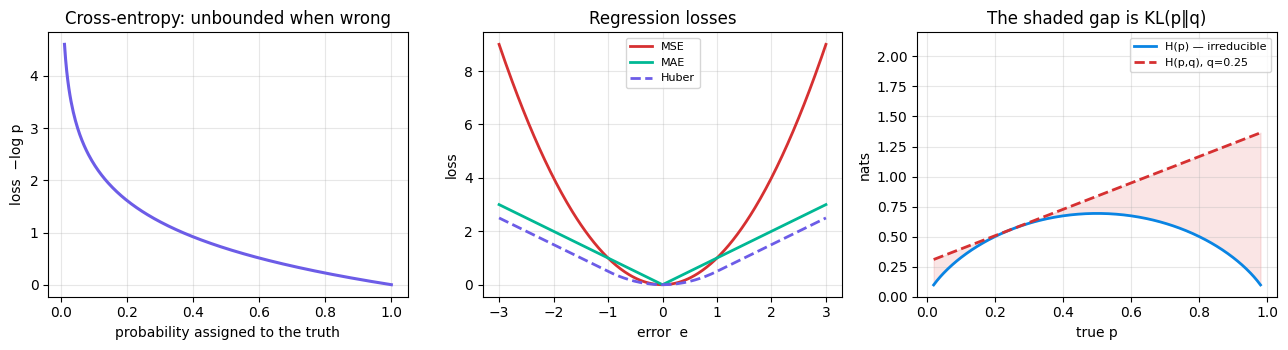

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

# -- surprisal ------------------------------------------------------------------
p = np.linspace(0.01, 1, 300)
ax[0].plot(p, -np.log(p), color='#6c5ce7', lw=2.2)
ax[0].set_xlabel('probability assigned to the truth')
ax[0].set_ylabel('loss  −log p')
ax[0].set_title('Cross-entropy: unbounded when wrong')
ax[0].grid(alpha=0.3)

# -- regression losses ----------------------------------------------------------
e = np.linspace(-3, 3, 300)
d = 1.0
ax[1].plot(e, e**2, color='#d63031', lw=2, label='MSE')
ax[1].plot(e, np.abs(e), color='#00b894', lw=2, label='MAE')
ax[1].plot(e, np.where(np.abs(e) <= d, 0.5*e**2, d*(np.abs(e) - 0.5*d)),
           color='#6c5ce7', lw=2, ls='--', label='Huber')
ax[1].set_xlabel('error  e'); ax[1].set_ylabel('loss')
ax[1].set_title('Regression losses')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

# -- entropy and cross-entropy --------------------------------------------------
pp = np.linspace(0.02, 0.98, 300)
H = -(pp*np.log(pp) + (1-pp)*np.log(1-pp))
q = 0.25
CE = -(pp*np.log(q) + (1-pp)*np.log(1-q))
ax[2].plot(pp, H, color='#0984e3', lw=2, label='H(p) — irreducible')
ax[2].plot(pp, CE, color='#d63031', lw=2, ls='--', label='H(p,q), q=0.25')
ax[2].fill_between(pp, H, CE, color='#d63031', alpha=0.12)
ax[2].set_ylim(0, 2.2)
ax[2].set_xlabel('true p'); ax[2].set_ylabel('nats')
ax[2].set_title('The shaded gap is KL(p‖q)')
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## What You Built

*Linear algebra* — dot products as similarity, matrix multiplication as a grid of
dot products, the shape rules, `nn.Linear` reproduced by hand, and the broadcasting
case that fails silently.

*Calculus* — six derivative rules verified numerically, gradient checking, the chain
rule, summing over paths (and the `zero_grad()` bug it causes), and gradient descent
converging and diverging.

*Probability and loss* — BCE from the Bernoulli likelihood, softmax with and without
the max-subtraction trick, cross-entropy from the categorical likelihood, the
`ŷ - y` gradient verified analytically and numerically and by autograd, MSE vs MAE
vs Huber under an outlier, and entropy / KL / perplexity.

## Next

[Lesson 01](../01_nn_from_scratch/prompt.ipynb) uses all three at once: it computes
a forward pass with matrix multiplies, a BCE loss, and every gradient in a two-layer
network by applying the chain rule layer by layer. That is backpropagation — and
after this notebook it introduces no new mathematics at all.